In [2]:
import skimage.io as io
import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
import pandas as pd
from pyvista import examples
from skimage.color import rgb2gray
import glob as glob
import cv2
%matplotlib inline
pv.set_jupyter_backend('trame')

In [3]:
def plot_mesh(Qn):
    x, y = np.mgrid[0:Qn.shape[0], 0:Qn.shape[1]]
    grid = pv.StructuredGrid(x, y , Qn, force_float=False)
    grid_tub = grid.elevation()


    pv.global_theme.background = 'white'
    pv.global_theme.font.color = 'black'
    pv.global_theme.edge_color = 'white'

    pl = pv.Plotter(shape=(1, 1),off_screen=True)

    pl.subplot(0, 0)
    pl.add_mesh(grid_tub,lighting=False,opacity=1.0,smooth_shading=True,show_scalar_bar=False)
    #pl.add_mesh(grid,opacity=1.0, smooth_shading=True)
    #pl.add_text("Raw", color='k')
    pl.camera_position = (0, 0, 844.1376029929585)
    pl.background_color = 'white'

    #pl.save_graphic("face.svg")  
    #pl.screenshot('face.png')
    pl.show()

def plot_ImArr(Qn):
    fig, ax =  plt.subplots(1,1,figsize=(12,7))
    ax.imshow(Qn,cmap='gray')

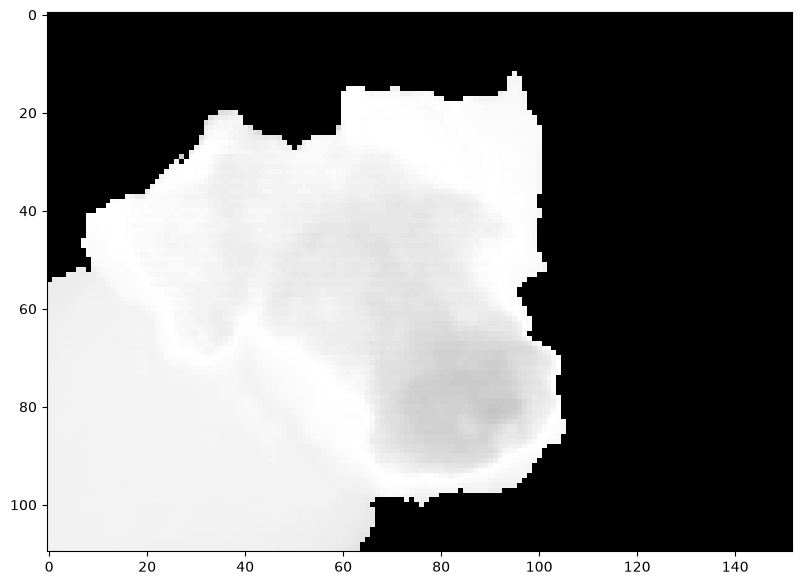

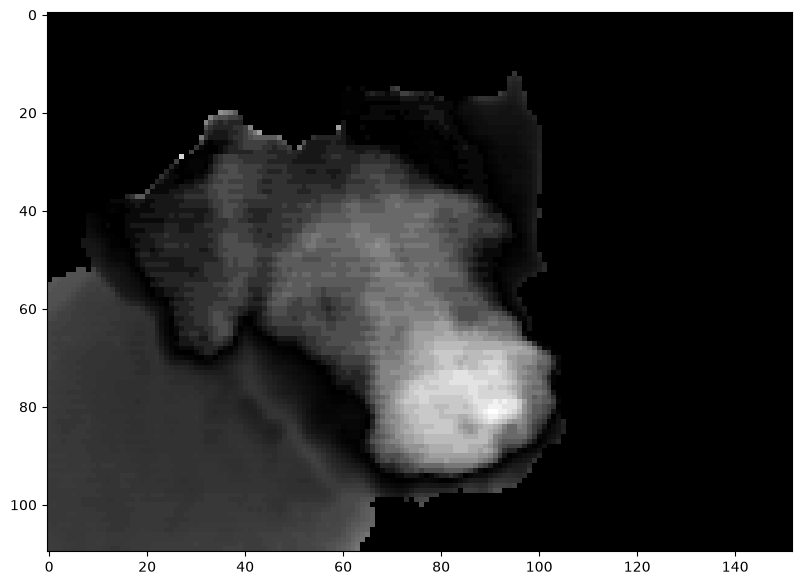

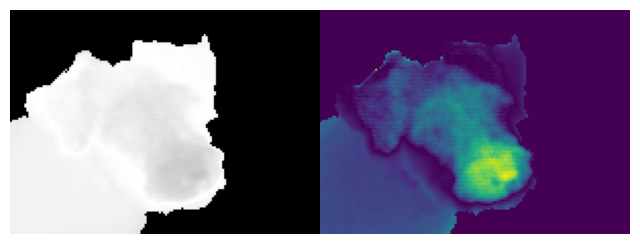

In [4]:
file= 'renders/dogo.png'
Z = io.imread(file)
zn = rgb2gray(Z)

minz = min(zn.ravel())
maxz = max(zn.ravel())

zn = (zn-minz)/(maxz-minz)
qn = np.zeros(zn.shape)

X = zn > 0
qn[X]=1-zn[X]

plot_ImArr(zn)
plot_ImArr(qn)

fig, ((ax1,ax2)) =  plt.subplots(1,2,figsize=(8,7))
ax1.imshow(zn,cmap='gray')
ax2.imshow(qn)
ax1.set_axis_off()
ax2.set_axis_off()
plt.subplots_adjust(wspace=0, hspace=0)
#plt.savefig("convexity.png", dpi=150)
#plot_mesh(qn)

In [5]:
plot_mesh(100*qn)

2026-09-11 11:01:46.010 (  11.628s) [    7FBD1B62C740]        vtkRenderer.cxx:1144  WARN| vtkOpenGLRenderer (0x63287c3cc7b0): Resetting view-up since view plane normal is parallel


Widget(value='<iframe src="http://localhost:39785/index.html?ui=P_0x7fbcaab3a7b0_0&reconnect=auto" class="pyvi…

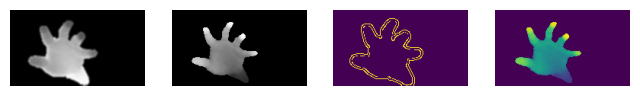

In [6]:
file= 'renders/hand.png'
Z = io.imread(file)
zn = rgb2gray(Z)

zn = (zn-minz)/(maxz-minz)
qn = np.zeros(zn.shape)

X = zn > 0
qn[X]=1-zn[X]

rn = qn
###################

pn = cv2.normalize(qn, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
edges = cv2.Canny(pn, threshold1=10, threshold2=300)
W = edges > 0

Y = qn> 0
qmax = max(qn[Y].ravel())
Z = qn > 0.76*qmax
qn[Z]=0.0
qn[W]=0.0
pnn = cv2.normalize(qn, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
# Apply Laplacian operator
laplacian = cv2.Laplacian(pnn, cv2.CV_64F)
 
# Convert to uint8
laplacian_abs = cv2.convertScaleAbs(laplacian)
Q =laplacian_abs > 15
qn[Q] = 0.0
###################

fig, ((ax1,ax4,ax3,ax2)) =  plt.subplots(1,4,figsize=(8,7))
ax1.imshow(zn,cmap='gray')
ax4.imshow(rn,cmap='gray')
ax2.imshow(qn)
ax3.imshow(edges)

ax1.set_axis_off()
ax2.set_axis_off()
ax3.set_axis_off()
ax4.set_axis_off()
#plt.subplots_adjust(wspace=0, hspace=0)
#plt.savefig("convexity.png", dpi=150)

In [7]:
plot_mesh(100*qn)

2026-09-11 11:01:57.755 (  23.373s) [    7FBD1B62C740]        vtkRenderer.cxx:1144  WARN| vtkOpenGLRenderer (0x63287d5ed350): Resetting view-up since view plane normal is parallel


Widget(value='<iframe src="http://localhost:39785/index.html?ui=P_0x7fbc9c1cd590_1&reconnect=auto" class="pyvi…